# 08 - Stage 4b features explained

A deep-dive companion to `07_features_qa.ipynb`. **07 is for cross-image QA** (timing,
heatmaps, sanity); **08 is for understanding what each feature actually measures** and
why it was chosen. Use this as standalone reference material when you're tuning the
modeling stage or explaining the feature set.

**Reading guide.** Each of the 9 feature families gets its own section with:
1. **What it is** -- compact math / algorithm definition.
2. **What it measures physically** -- planetary-geomorphology framing.
3. **Why we picked it** -- references + the role it plays in the feature stack.
4. **Visual example on real data** -- per-image distribution and (where useful) a
   per-tile illustration on `ESP_069669_2220` (canonical boulder-rich, S3 peak 0.88).

**Section index:**

| § | Family | n_cols | Available at | Best signal so far |
|---|---|---:|---|---|
| 1 | `intensity_stats`         | 10 | all scales | `intensity_std` (+0.035 with fractional_area) |
| 2 | `glcm`                    | 18 | all scales (NaN-padded) | `glcm_contrast_d1` (+0.033) |
| 3 | `gradient`                |  5 | all scales | `grad_mag_mean` (+0.028) |
| 4 | `shadow_fraction` + bright|  3 | all scales | `shadow_fraction_strict` (+0.083, top positive) |
| 5 | `lbp`                     | 10 | all scales | weak (-0.020 to +0.014) |
| 6 | `lacunarity`              |  2 | S >= 32 only | TBD (zero finest correlation, S>=32 not in S=8 corr table) |
| 7 | `subtile_variance`        |  1 | S >= 16 only | TBD (NaN at S=8) |
| 8 | `canny_edges`             |  2 | S >= 16 only | TBD |
| 9 | `context_patch`           |  2 (refs) | all scales | Visual only |

§10 below holds the **stratified boulder-rich-vs-boulder-poor patch viewer** -- the
visual investigation aid the user explicitly requested. It samples patches across the 9
images stratified by `fractional_area` so you can see where the visible-boulder threshold
lives and judge what kind of label (binary / regression / categorical) the imagery
actually supports.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
import numpy as np
import pandas as pd
import rasterio

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import manifest as M
from src.config import load_config
from src.features import (
    FEATURES_SUBDIR, load_context_patches, load_features, load_features_provenance,
)
from src.labeling import LABELS_SUBDIR, load_labels, load_provenance

FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(REPO_ROOT / 'config.yaml')
manifest_df = M.load_manifest(cfg.manifest_path).set_index('ObsId')

obs_ids = []
for obs in manifest_df.index:
    if (cfg.output_dir / FEATURES_SUBDIR / f'{obs}.parquet').exists():
        obs_ids.append(obs)
print(f'{len(obs_ids)} ObsIds with Stage 4b outputs: {obs_ids}')

LABEL_COLORS = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue', 'unknown': 'tab:gray'}

# Load everything once. The combined finest-scale dataframe is what every per-family
# figure draws from; we also build a small per-image features dict for visualisations
# that need per-image context (e.g. shadow histogram).
def join_one(obs):
    feats = load_features(obs, cfg.output_dir)
    labels = load_labels(obs, cfg.output_dir)
    join = labels.merge(feats, on=['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj'])
    join['label'] = manifest_df.loc[obs, 'BoulderLabel']
    return join

joined = pd.concat([join_one(o) for o in obs_ids], ignore_index=True)
finest = joined[joined['tile_size_px'] == joined['tile_size_px'].min()].copy()
print(f'finest-scale rows across all images: {len(finest):,} '
      f'(fraction zero = {(finest["fractional_area"] == 0).mean():.1%})')


9 ObsIds with Stage 4b outputs: ['ESP_055714_2270', 'ESP_054857_2270', 'ESP_069669_2220', 'ESP_071093_2210', 'ESP_047976_2020', 'ESP_056165_2200', 'ESP_075577_2105', 'ESP_039820_1750', 'ESP_065711_1545']


finest-scale rows across all images: 488,554 (fraction zero = 97.9%)


## 1. `intensity_stats` -- raw radiometric reductions over each tile

**What it is.** For each tile, reduce the uint8 CTX DN values into 10 scalar
statistics: `mean`, `std`, `min`, `max`, `p10`, `p50`, `p90`, `IQR = p75 - p25`,
`skewness`, `kurtosis` (excess). All are computed in float64 over a `(n_tiles, S*S)`
reshape, so per-tile costs are O(S^2) with no extra Python loop.

**What it measures physically.** Pure radiometry -- "how bright is this patch of
ground, and how spread-out are the brightnesses?" Boulder-rich terrain tends to
- shift *down* in `mean` (boulder shadows darken the average DN) and
- shift *up* in `std`, `IQR`, and especially `skewness` (left tail from shadows
  + occasional right outliers from sunlit boulder tops).

**Why we picked it.** Cheapest possible features -- a baseline that any more expensive
texture descriptor has to beat. Higher-order moments (`skewness`, `kurtosis`) were added
2026-05-23 because shadow-induced left tails are exactly the signal a single std can't
capture; Bandeira et al. 2007 used skewness for HiRISE-scale dune-field detection.

**Visual example.** Below: per-image distributions of `intensity_mean`, `intensity_std`,
and `intensity_skewness` colored by `BoulderLabel`. The mean shift between rich and
poor images is dramatic; the std shift is subtler; skewness is the most discriminative
of the three at first glance.


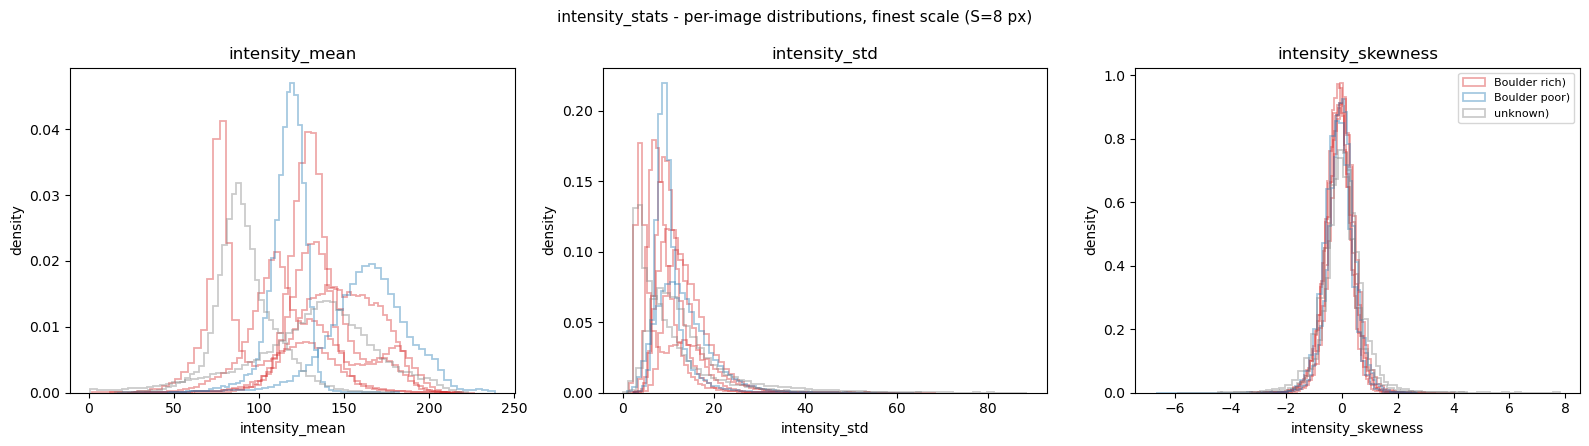

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['intensity_mean', 'intensity_std', 'intensity_skewness']):
    for obs in obs_ids:
        sub = finest[finest['obs_id'] == obs]
        lab = sub['label'].iloc[0]
        ax.hist(sub[col].dropna(), bins=60, alpha=0.4, color=LABEL_COLORS[lab],
                density=True, histtype='step', linewidth=1.3, label=f'{obs} ({lab})')
    ax.set_xlabel(col)
    ax.set_ylabel('density')
    ax.set_title(col)
# Legend on the rightmost panel only, condensed.
handles, labels = axes[-1].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    key = l.split('(')[-1]
    seen.setdefault(key, h)
axes[-1].legend(seen.values(), seen.keys(), fontsize=8, loc='upper right')
fig.suptitle('intensity_stats - per-image distributions, finest scale (S=8 px)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_intensity_stats_per_image.png', dpi=110)
plt.show()


## 2. `glcm` -- gray-level co-occurrence matrix texture descriptors

**What it is.** For each tile, quantize CTX DN values into `levels` bins (8/16/16/32 per
scale; see Clausi 2002 -- tiny tiles can't fill big co-occurrence matrices). Build the
co-occurrence matrix \(P(i,j; d, \theta)\) = "probability that pixel of intensity-bin
$i$ is followed at offset $(d, \theta)$ by pixel of intensity-bin $j$" symmetrised over
$\pm d$. Then compute 6 second-order moments via `skimage.feature.graycoprops`:

- `contrast` $= \sum_{i,j} (i-j)^2 P(i,j)$ -- weighted-difference energy.
- `dissimilarity` $= \sum_{i,j} |i-j| P(i,j)$ -- linear analog of contrast.
- `homogeneity` $= \sum_{i,j} P(i,j) / (1 + (i-j)^2)$ -- "diagonal-heavy" -> high.
- `energy` $= \sqrt{\sum_{i,j} P(i,j)^2}$ -- concentration of mass.
- `ASM` = energy^2 (same idea, no square root).
- `correlation` -- normalized GLCM correlation; can NaN on uniform tiles.

We average over the 4 angles $\{0, \pi/4, \pi/2, 3\pi/4\}$ for rotation invariance and
emit one column per (property, distance).

**What it measures physically.** GLCM is the canonical *texture* descriptor: it asks
"do neighboring pixels at offset $d$ tend to have similar or different intensities?"
- `contrast` / `dissimilarity` rise with sharp DN transitions = boulder edges.
- `homogeneity` / `energy` / `ASM` rise with uniform smooth terrain.
- `correlation` measures how well intensity at one location predicts intensity nearby.

At CTX 5 m/px under typical sun angles, a single resolved boulder produces a 1-3 px-wide
shadow next to a 1-2 px-wide bright cap -- so co-occurrence at $d \in \{1, 2, 3\}$
brackets that signature.

**Why we picked it.** Haralick GLCM features are the workhorse of remote-sensing texture
analysis. They're mature, fast, robust at small tile sizes, and produce 6 features per
distance for almost no incremental compute given the cached quantization.

**Visual example.** Two panels below:
- Left: `glcm_contrast_d1` distribution per image, finest scale.
- Right: contrast vs distance for one boulder-rich image (ESP_069669_2220) -- showing
  how the 3 distances probe different spatial frequencies.


C:\Users\brian\AppData\Local\Temp\ipykernel_162380\1646745067.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([vals[c] for c in dist_cols], labels=['d=1', 'd=2', 'd=3'],


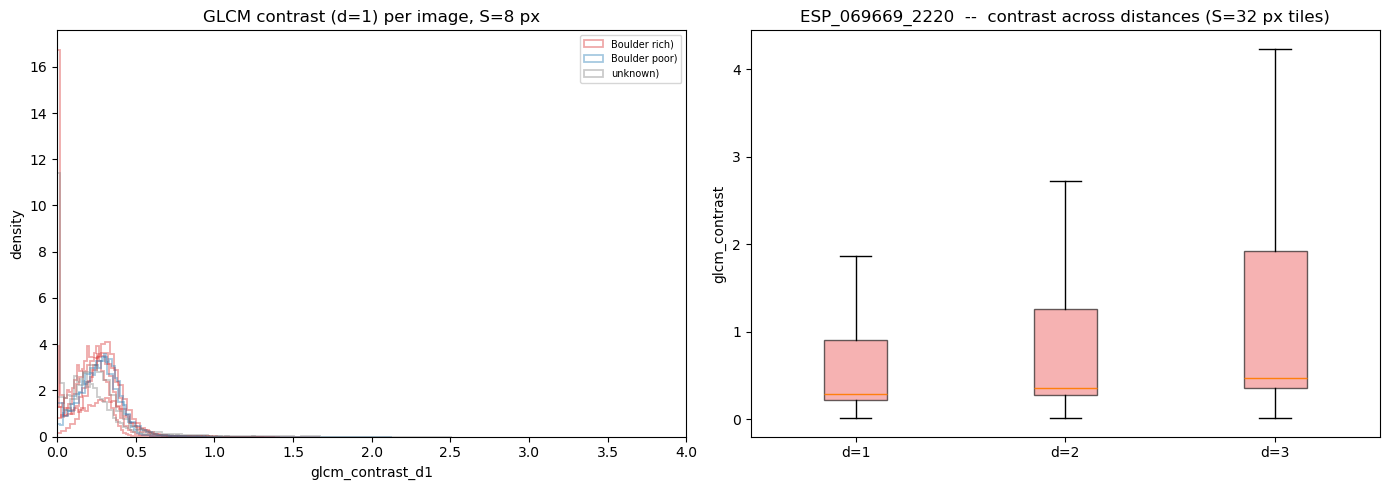

GLCM contrast (median) by distance, ESP_069669_2220:
  S=16 px: d=1=0.300  d=2=0.381  d=3=0.495
  S=32 px: d=1=0.282  d=2=0.359  d=3=0.472
  S=64 px: d=1=0.577  d=2=0.812  d=3=1.283


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: contrast_d1 distribution per image, finest scale (only d1 is valid there).
for obs in obs_ids:
    sub = finest[finest['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    vals = sub['glcm_contrast_d1'].dropna()
    if len(vals):
        axes[0].hist(vals, bins=60, alpha=0.4, color=LABEL_COLORS[lab], density=True,
                     histtype='step', linewidth=1.3, label=f'{obs} ({lab})')
axes[0].set_xlabel('glcm_contrast_d1')
axes[0].set_ylabel('density')
axes[0].set_title('GLCM contrast (d=1) per image, S=8 px')
axes[0].set_xlim(0, 4)

# Right: contrast across distances at coarser scale where d2/d3 are valid.
ref_obs = 'ESP_069669_2220' if 'ESP_069669_2220' in obs_ids else obs_ids[0]
sub_ref = joined[(joined['obs_id'] == ref_obs) & (joined['tile_size_px'] == 32)]
dist_cols = ['glcm_contrast_d1', 'glcm_contrast_d2', 'glcm_contrast_d3']
vals = sub_ref[dist_cols].dropna()
axes[1].boxplot([vals[c] for c in dist_cols], labels=['d=1', 'd=2', 'd=3'],
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', alpha=0.6))
axes[1].set_ylabel('glcm_contrast')
axes[1].set_title(f'{ref_obs}  --  contrast across distances (S=32 px tiles)')

handles, labels = axes[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    key = l.split('(')[-1]
    seen.setdefault(key, h)
axes[0].legend(seen.values(), seen.keys(), fontsize=7, loc='upper right')

fig.tight_layout()
fig.savefig(FIG_DIR / '08_glcm_per_image.png', dpi=110)
plt.show()

# Print the GLCM contrast quantiles per scale for ESP_069669_2220 -- shows how distance
# probes different texture lengthscales.
print('GLCM contrast (median) by distance, ESP_069669_2220:')
for s in [16, 32, 64]:
    sub = joined[(joined['obs_id'] == ref_obs) & (joined['tile_size_px'] == s)]
    row = {f'd={d}': sub[f'glcm_contrast_d{d}'].median() for d in [1, 2, 3]}
    print(f'  S={s} px: ' + '  '.join(f'{k}={v:.3f}' for k, v in row.items() if v == v))


## 3. `gradient` -- Sobel gradient magnitude + direction

**What it is.** Smooth the CTX window with a $\sigma = 1$ Gaussian (low-pass against
sensor noise), then convolve with the Sobel kernels along each axis. Per-tile reductions
of the magnitude $|\nabla I| = \sqrt{g_x^2 + g_y^2}$:

- `grad_mag_mean`, `grad_mag_std`, `grad_mag_p90`, `grad_mag_p99` -- the p99 is for the
  rare strong-edge outliers that saturate p90 in busy tiles (added 2026-05-23).
- `grad_dir_circvar` -- magnitude-weighted circular variance of $\arctan2(g_y, g_x)$
  with the angle doubled to fold 180-deg edge ambiguity (a horizontal edge has direction
  0 or $\pi$ depending on which side is brighter; we treat both as the same edge).

**What it measures physically.** Sobel gradient magnitude is the most direct edge-
density proxy: high gradient = sharp intensity transition. For boulder fields this maps
onto:
- Many small bright caps + dark shadows -> bursts of high magnitude.
- Smooth dust-covered plains -> low magnitude everywhere.

Circular variance in [0, 1] reports whether the strong edges are *oriented*
(low circvar -- lineations, slopes, dunes) or *random* (high circvar -- boulder field).

**Why we picked it.** Sobel is the cheapest mid-tier feature -- one full-window
convolution per image, then per-tile reductions are reshape-and-reduce. The whole family
runs in well under a second per image at our window sizes. The circular variance is a
free directional-anisotropy signal on top.

**Visual example.** Distribution of `grad_mag_mean` per image (left) and a scatter
showing how `grad_mag_p99` separates boulder-rich from boulder-poor tiles where the mean
saturates (right).


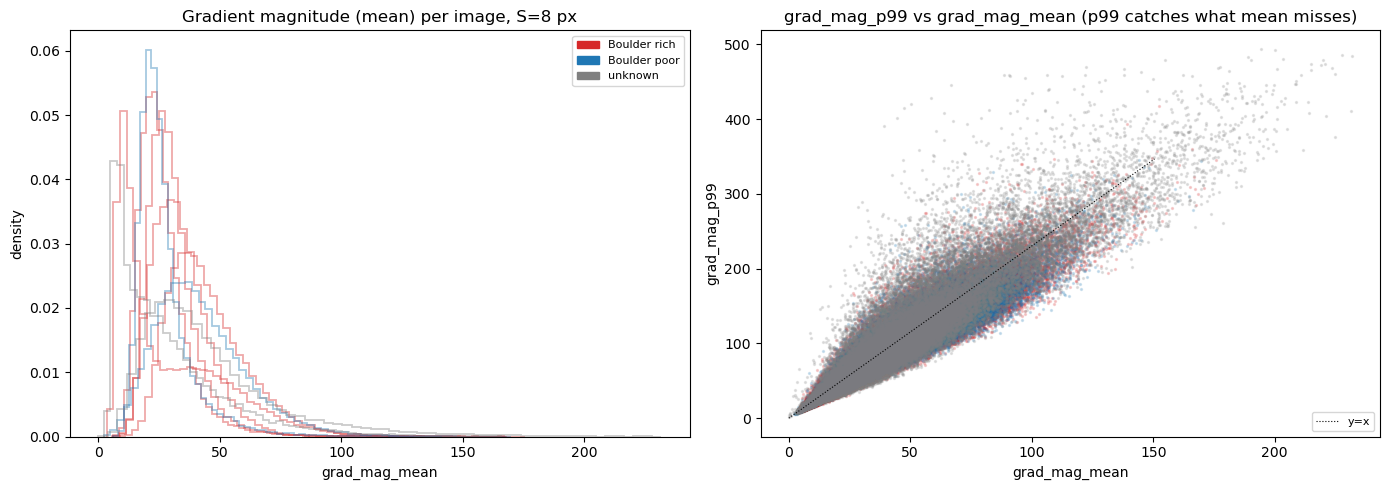

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for obs in obs_ids:
    sub = finest[finest['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    axes[0].hist(sub['grad_mag_mean'].dropna(), bins=60, alpha=0.4,
                 color=LABEL_COLORS[lab], density=True, histtype='step', linewidth=1.3,
                 label=f'{obs} ({lab})')
axes[0].set_xlabel('grad_mag_mean')
axes[0].set_ylabel('density')
axes[0].set_title('Gradient magnitude (mean) per image, S=8 px')

# Right: scatter p99 vs mean, colored by label.
for obs in obs_ids:
    sub = finest[finest['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    axes[1].scatter(sub['grad_mag_mean'], sub['grad_mag_p99'],
                    s=2, alpha=0.18, color=LABEL_COLORS[lab])
axes[1].set_xlabel('grad_mag_mean')
axes[1].set_ylabel('grad_mag_p99')
axes[1].set_title('grad_mag_p99 vs grad_mag_mean (p99 catches what mean misses)')
axes[1].plot([0, finest['grad_mag_mean'].quantile(0.999)],
             [0, finest['grad_mag_p99'].quantile(0.999)],
             color='k', linestyle=':', linewidth=0.8, label='y=x')
axes[1].legend(loc='lower right', fontsize=8)
# Label-legend in left panel.
patches_leg = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
axes[0].legend(handles=patches_leg, fontsize=8, loc='upper right')

fig.tight_layout()
fig.savefig(FIG_DIR / '08_gradient_per_image.png', dpi=110)
plt.show()


## 4. `shadow_fraction` + `shadow_fraction_strict` + `bright_cap_fraction`

**What it is.** Per image, compute `mode_DN` = `argmax(np.bincount(ctx_window[mask==1]))`
-- one bincount over HiRISE-mask-covered pixels. Derive three absolute DN cuts:

- `shadow_threshold = mode_DN - 20`
- `shadow_threshold_strict = mode_DN - 35`
- `bright_threshold = mode_DN + 30`

Per tile, emit the three fractions `mean(arr < threshold)` / `mean(arr > threshold)`.

**What it measures physically.** This is the most directly physical boulder feature in
the stack: on Mars at HiRISE/CTX scale, individual resolved boulders are 3-D objects on
a flat surface. A typical sun angle of 30-50 deg produces:

- An adjacent **shadow patch** (DN much less than terrain mean).
- A **sunlit cap** (DN higher than terrain mean).

So the shadow-bright asymmetry is the photometric signature of 3-D relief. This is the
same intuition behind Kirk et al. 2008 photoclinometry for HiRISE DTMs, taken down to
two scalar per-tile features instead of a per-pixel inversion.

**Why we picked it (and why DN-mode over image-percentile).** The DN modes we observed
across the 9-image sweep span 77 to 166 -- more than a factor of 2. A single image-
percentile threshold (e.g. "DN below the 10th percentile") would assign different
absolute DN cuts to different images, so a tile with the same physical shadow content
would get different `shadow_fraction` values across images. Anchoring on `mode_DN`
fixes that: the shadow cut is always "the same dark-relative-to-terrain offset" in
absolute DN, so the column is meaningful cross-image.

Empirically: `shadow_fraction_strict` is currently the top positive correlation with
`fractional_area` (+0.083) across the whole 488k finest-tile dataset.

**Visual example.** Per-image DN histograms with mode + thresholds annotated (left),
and shadow_fraction distribution per image (right).


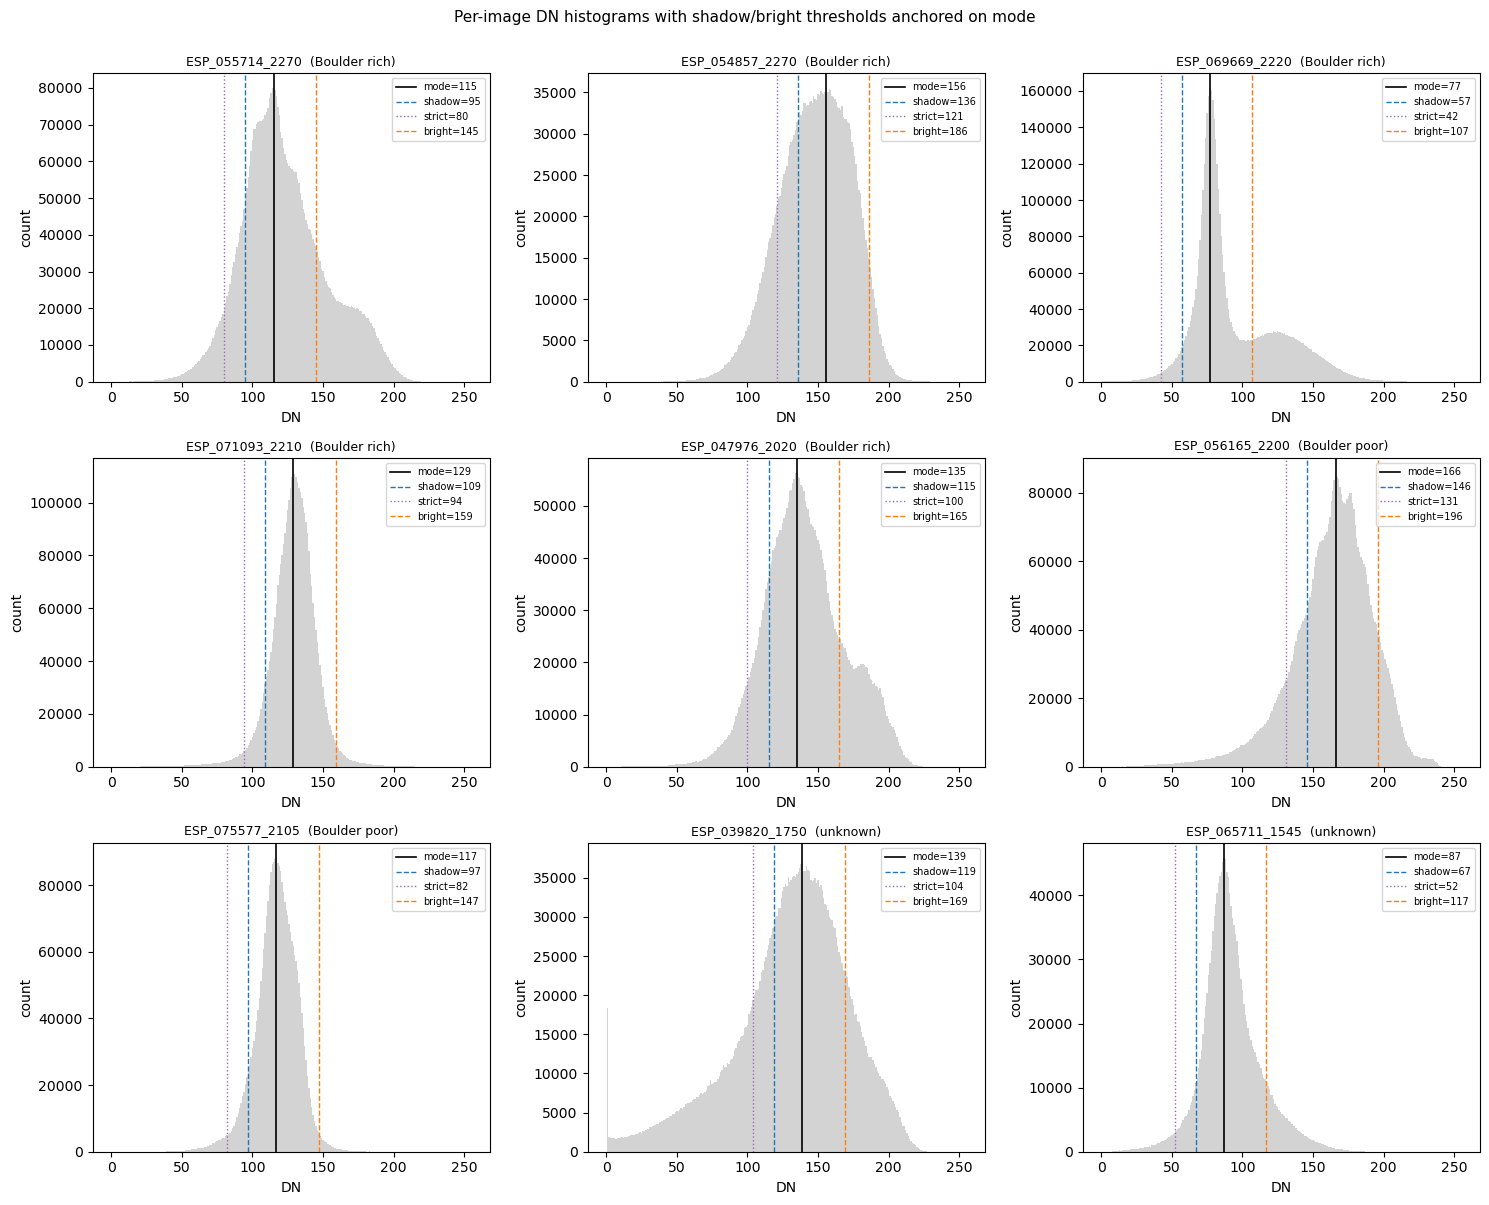

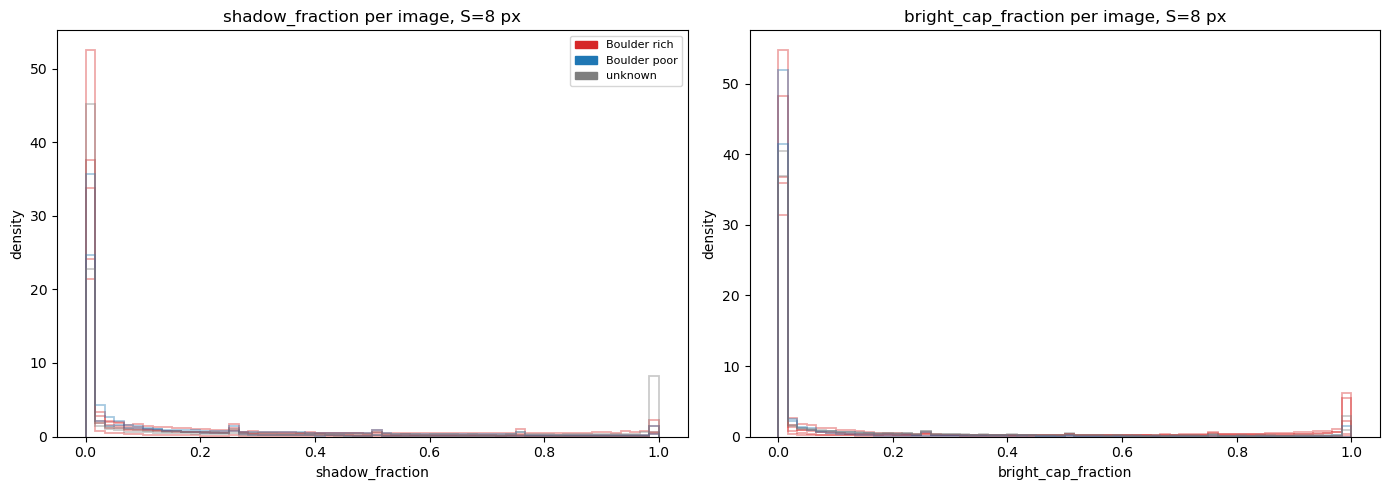

In [5]:
# DN histogram + thresholds, one panel per image, 3x3 grid.
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, obs in zip(axes.flat, obs_ids):
    prov = load_features_provenance(obs, cfg.output_dir)
    dn = prov['dn_thresholds']
    ctx_path = Path(prov['ctx_window_tif'])
    mask_path = Path(prov['hirise_mask_tif'])
    with rasterio.open(ctx_path) as src:
        arr = src.read(1)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    covered = arr[mask == 1]
    counts = np.bincount(covered, minlength=256)
    ax.bar(range(256), counts, width=1, color='lightgray', edgecolor='none')
    ax.axvline(dn['mode'], color='k', linestyle='-', linewidth=1.2, label=f'mode={dn["mode"]}')
    ax.axvline(dn['shadow'], color='tab:blue', linestyle='--', linewidth=1, label=f'shadow={dn["shadow"]}')
    ax.axvline(dn['shadow_strict'], color='tab:purple', linestyle=':', linewidth=1, label=f'strict={dn["shadow_strict"]}')
    ax.axvline(dn['bright'], color='tab:orange', linestyle='--', linewidth=1, label=f'bright={dn["bright"]}')
    lab = manifest_df.loc[obs, 'BoulderLabel']
    ax.set_title(f'{obs}  ({lab})', fontsize=9)
    ax.set_xlabel('DN'); ax.set_ylabel('count')
    ax.legend(fontsize=7, loc='upper right')
fig.suptitle('Per-image DN histograms with shadow/bright thresholds anchored on mode',
             fontsize=11, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_dn_histograms.png', dpi=110)
plt.show()

# Per-image shadow_fraction distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for obs in obs_ids:
    sub = finest[finest['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    axes[0].hist(sub['shadow_fraction'].dropna(), bins=60, alpha=0.4,
                 color=LABEL_COLORS[lab], density=True, histtype='step', linewidth=1.3)
    axes[1].hist(sub['bright_cap_fraction'].dropna(), bins=60, alpha=0.4,
                 color=LABEL_COLORS[lab], density=True, histtype='step', linewidth=1.3)
axes[0].set_xlabel('shadow_fraction'); axes[0].set_ylabel('density')
axes[0].set_title('shadow_fraction per image, S=8 px')
axes[1].set_xlabel('bright_cap_fraction'); axes[1].set_ylabel('density')
axes[1].set_title('bright_cap_fraction per image, S=8 px')
patches_leg = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
axes[0].legend(handles=patches_leg, fontsize=8, loc='upper right')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_shadow_bright_per_image.png', dpi=110)
plt.show()


## 5. `lbp` -- Local Binary Patterns (rotation-invariant uniform)

**What it is.** For each pixel, compare it to its 8 circular neighbors at radius 1.
Each neighbor produces a bit: 1 if the neighbor is brighter, 0 otherwise -- so each
pixel gets an 8-bit pattern. `skimage` then maps these to 10 distinct labels using the
rotation-invariant uniform encoding (`method='uniform'`):
- 9 labels for *uniform* patterns (patterns with at most 2 transitions in their circular
  bit string), one per "number of 1s" in the pattern, rotation-collapsed.
- 1 label for *non-uniform* patterns (lumped together).

Per tile, the histogram of these 10 labels is normalized to sum to 1 and emitted as
`lbp_hist_0` ... `lbp_hist_9`.

**What it measures physically.** LBP is a *micro-texture* descriptor: the histogram
characterises *what kinds of small-scale pixel patterns* are most common in the tile.
A uniform smooth surface produces mostly "all zeros" or "all ones" patterns (flat
neighborhoods); a textured boulder field produces a balanced mix of intermediate counts.
Because LBP only encodes *signs* of differences, it's invariant to monotonic illumination
changes -- a tile that's globally darker but with the same pattern frequencies has the
same LBP histogram.

**Why we picked it.** LBP gives texture information *complementary* to GLCM: GLCM
encodes pair statistics ("how often does intensity i sit next to intensity j?"), LBP
encodes pattern statistics ("how often does a pixel sit in a 'mostly brighter' vs
'mostly darker' neighborhood?"). Mars precedent: Palafox et al. 2017 (geological
landform detection on HiRISE-class imagery).

**Visual example.** Per-image average LBP histogram, colored by label. Boulder-rich vs
poor images should differ in which bins they put weight on -- if the dataset is too
small for crisp separation here we'll note it.


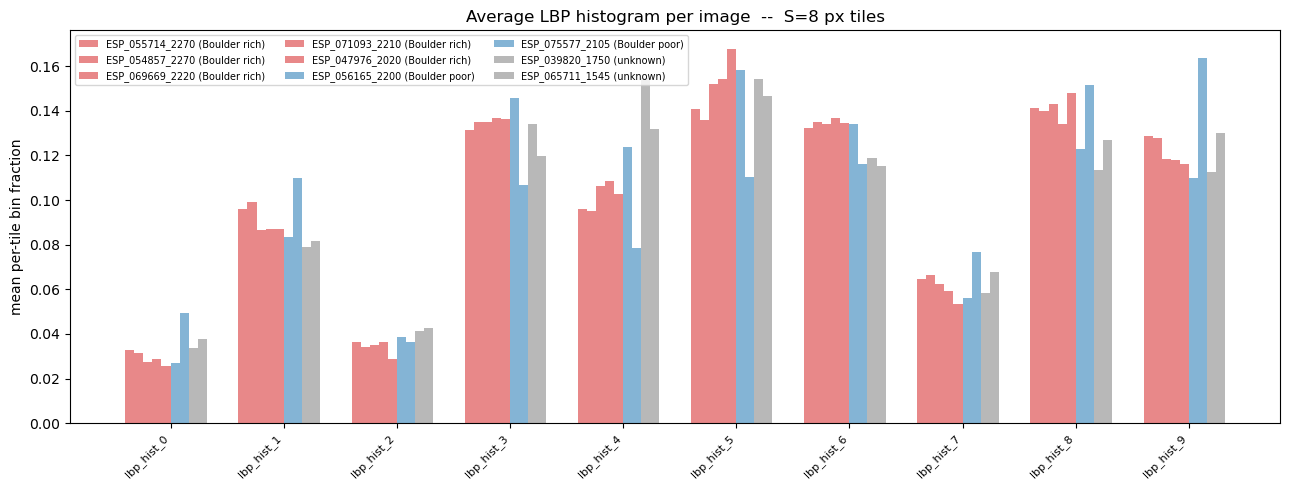

Mean LBP histogram by BoulderLabel (S=8):
              lbp_hist_0  lbp_hist_1  lbp_hist_2  lbp_hist_3  lbp_hist_4  lbp_hist_5  lbp_hist_6  lbp_hist_7  lbp_hist_8  lbp_hist_9
label                                                                                                                               
Boulder poor       0.036       0.093       0.038       0.131       0.107       0.140       0.127       0.064       0.134       0.130
Boulder rich       0.029       0.091       0.034       0.135       0.102       0.150       0.134       0.061       0.141       0.122
unknown            0.035       0.080       0.042       0.129       0.147       0.152       0.118       0.062       0.118       0.119


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
lbp_cols = [f'lbp_hist_{k}' for k in range(10)]
bin_centers = np.arange(10)
width = 0.08
for i, obs in enumerate(obs_ids):
    sub = finest[finest['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    means = sub[lbp_cols].mean()
    offset = (i - len(obs_ids) / 2) * width
    ax.bar(bin_centers + offset, means.values, width=width,
           color=LABEL_COLORS[lab], alpha=0.55,
           label=f'{obs} ({lab})')
ax.set_xticks(bin_centers)
ax.set_xticklabels(lbp_cols, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('mean per-tile bin fraction')
ax.set_title('Average LBP histogram per image  --  S=8 px tiles')
ax.legend(fontsize=7, ncol=3, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_lbp_per_image.png', dpi=110)
plt.show()

# Mean LBP per BoulderLabel, condensed -- shows which bins are discriminative.
print('Mean LBP histogram by BoulderLabel (S=8):')
print(finest.groupby('label')[lbp_cols].mean().round(3).to_string())


## 6. `lacunarity_shadow_b{2,4}` -- gappiness of the shadow pattern (S >= 32)

**What it is.** Lacunarity is a measure of spatial heterogeneity of a binary mask. For
each tile and each gliding-box size $b \in \{2, 4\}$ px:

1. Slide the b*b box over every position inside the tile.
2. At each position, count the shadow pixels (mask = 1) inside the box -> $M$.
3. Compute $L(b) = E[M^2] / E[M]^2$ where the expectation is over box positions.

$L = 1$ exactly when the shadow mask is perfectly uniform (every box has the same
count). $L > 1$ when shadows are clustered or gappy. Implemented via an integral image
so the per-tile cost is $O(S^2 + (S-b+1)^2)$ -- still cheap.

**What it measures physically.** Lacunarity addresses a question that `shadow_fraction`
alone can't: **are the shadows scattered evenly, or clumped?** A tile with 10% shadow
spread across many small isolated boulders has *different geomorphology* from a tile
with the same 10% concentrated under one big boulder or a cliff face -- and that
distinction matters for boulder counting / size-distribution downstream.

**Why we picked it.** Lacunarity has a long planetary-surfaces literature (Plesko et al.
2009, 2010 for lunar surface roughness). It directly addresses the "clustered vs
scattered" axis that no other feature in our stack captures. We restrict it to
$S \ge 32$ because below 16 px the number of valid box positions is too small for the
mean-and-second-moment statistics to be stable.

**Visual example.** Two synthetic tiles + their lacunarity values, then per-image
lacunarity distribution at S=32.


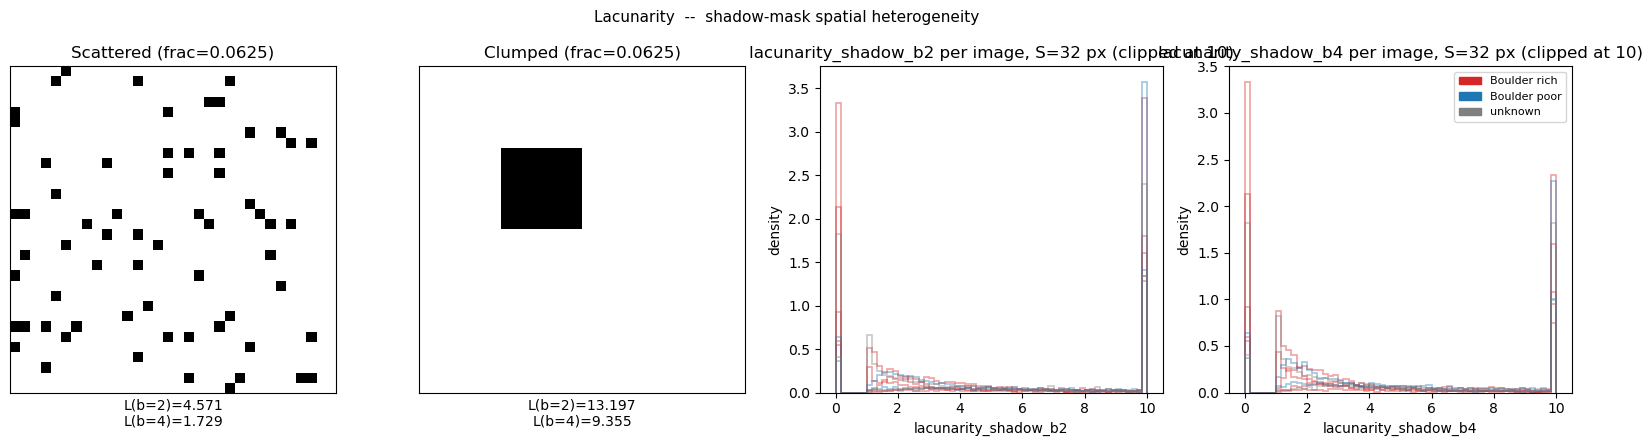

In [7]:
from src.features import _lacunarity_per_tile

# Synthetic demo -- two 32x32 shadow masks: scattered vs clumped, same shadow fraction.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

scattered = np.zeros((32, 32), dtype=np.uint8)
rng = np.random.default_rng(7)
scatter_idx = rng.choice(32 * 32, size=64, replace=False)
scattered.flat[scatter_idx] = 1

clumped = np.zeros((32, 32), dtype=np.uint8)
clumped[8:16, 8:16] = 1  # one 8x8 patch = 64 pixels, same total mass

for ax, mask, title in zip(axes[:2], [scattered, clumped],
                            ['Scattered (frac=0.0625)', 'Clumped (frac=0.0625)']):
    ax.imshow(mask, cmap='gray_r')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    out = _lacunarity_per_tile(
        mask, r_win=np.array([0]), c_win=np.array([0]), S=32, box_sizes=[2, 4],
    )
    ax.set_xlabel(f'L(b=2)={out["lacunarity_shadow_b2"][0]:.3f}\n'
                  f'L(b=4)={out["lacunarity_shadow_b4"][0]:.3f}', fontsize=10)

# Right two panels: per-image lacunarity distribution at S=32.
s32 = joined[joined['tile_size_px'] == 32]
for ax, col in zip(axes[2:], ['lacunarity_shadow_b2', 'lacunarity_shadow_b4']):
    for obs in obs_ids:
        sub = s32[s32['obs_id'] == obs]
        lab = sub['label'].iloc[0]
        vals = sub[col].dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals.clip(upper=10), bins=60, alpha=0.4, color=LABEL_COLORS[lab],
                density=True, histtype='step', linewidth=1.3)
    ax.set_xlabel(col)
    ax.set_ylabel('density')
    ax.set_title(f'{col} per image, S=32 px (clipped at 10)')
patches_leg = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
axes[3].legend(handles=patches_leg, fontsize=8, loc='upper right')

fig.suptitle('Lacunarity  --  shadow-mask spatial heterogeneity', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_lacunarity.png', dpi=110)
plt.show()


## 7. `intensity_subtile_var` -- variance of sub-block means (S >= 16)

**What it is.** For each tile at scale $S \ge 16$, divide the tile into 4 sub-blocks of
size $(S/2) \times (S/2)$. Compute the mean DN of each sub-block (a 2x2 array of
sub-means). Emit the variance of those 4 means.

**What it measures physically.** This is *block-level heterogeneity* -- how much do
the 4 quadrants of the tile differ from each other? It captures structured variance
that single-tile `intensity_std` washes out:

- A tile that's uniformly noisy has high `intensity_std` but low `subtile_var`
  (each quadrant has the same noisy mean).
- A tile that's smooth in 3 quadrants and rough in 1 has *lower* `intensity_std` but
  *higher* `subtile_var` (one mean stands out).

This is exactly the signal you want for "is one part of this tile dominated by something
different from the rest" -- which is a useful sanity feature for tile-boundary effects
and for catching half-boulder-rich, half-plains tiles.

**Why we picked it.** *Free*. The nested x2 grid means each $S \times S$ tile is
already 4 stacked finer tiles, and we have their means computed for `intensity_mean`
at the next-finer scale already. Computing the variance across them is a single
NumPy line. Standard planetary-roughness rationale: Shepard et al. 2001 ("The
roughness of natural terrain").

**Visual example.** Per-image distribution at S=16 and S=64, and a scatter against
`intensity_std` showing they're not perfectly correlated (i.e. the feature carries
information beyond what std has).


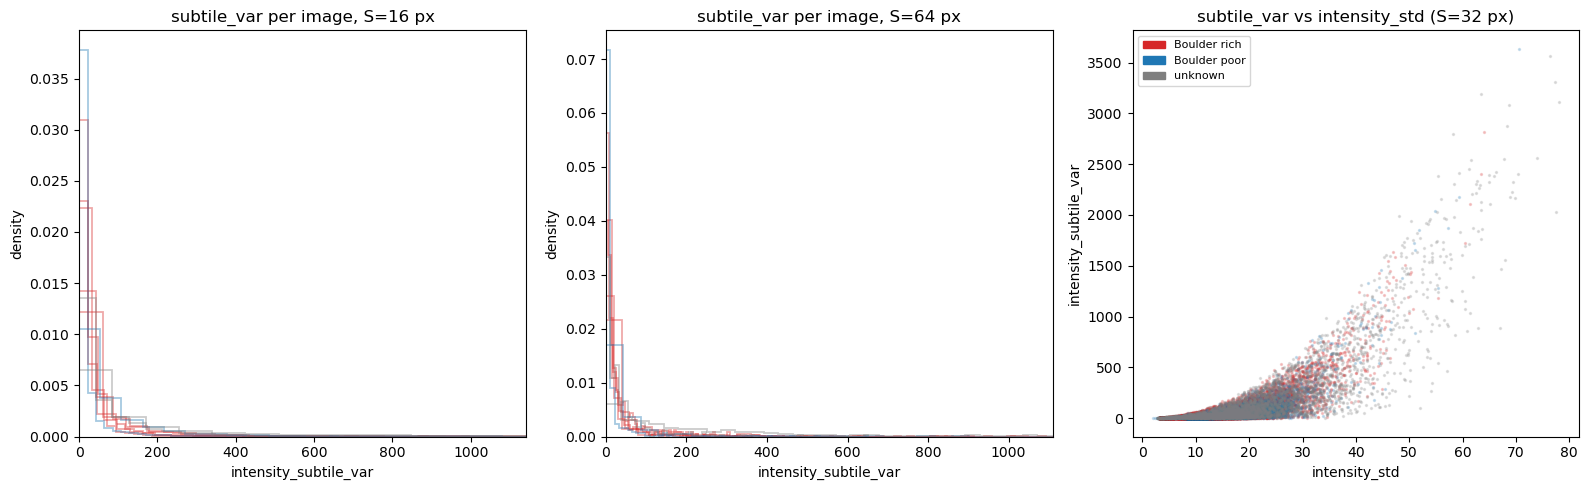

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, s in zip(axes[:2], [16, 64]):
    sub = joined[joined['tile_size_px'] == s]
    for obs in obs_ids:
        s_obs = sub[sub['obs_id'] == obs]
        lab = s_obs['label'].iloc[0]
        vals = s_obs['intensity_subtile_var'].dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=60, alpha=0.4, color=LABEL_COLORS[lab],
                density=True, histtype='step', linewidth=1.3)
    ax.set_xlabel('intensity_subtile_var')
    ax.set_ylabel('density')
    ax.set_title(f'subtile_var per image, S={s} px')
    ax.set_xlim(0, np.nanquantile(sub['intensity_subtile_var'], 0.995))

# Right: scatter subtile_var vs intensity_std at S=32, all images.
s32 = joined[joined['tile_size_px'] == 32]
for obs in obs_ids:
    sub = s32[s32['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    axes[2].scatter(sub['intensity_std'], sub['intensity_subtile_var'],
                    s=2, alpha=0.2, color=LABEL_COLORS[lab])
axes[2].set_xlabel('intensity_std')
axes[2].set_ylabel('intensity_subtile_var')
axes[2].set_title('subtile_var vs intensity_std (S=32 px)')

patches_leg = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
axes[2].legend(handles=patches_leg, fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_subtile_variance.png', dpi=110)
plt.show()


## 8. `canny_edges` -- edge density + orientation entropy (S >= 16)

**What it is.** Compute Canny edges once per CTX window (skimage `canny` with
$\sigma = 1.0$, default low/high thresholds). The Canny operator thresholds and
non-max-suppresses the gradient magnitude to produce a clean binary edge map. Per tile,
emit:

- `edge_density` = (Canny pixels in tile) / (tile pixels).
- `edge_orientation_entropy` = Shannon entropy of the gradient *direction* histogram at
  the Canny pixels, binned over $[0, \pi)$ in 8 bins. 0 if no edges; up to $\log 8
  \approx 2.08$ for perfectly isotropic edge orientations.

**What it measures physically.** Edge density is a *cleaner* edge signal than gradient
magnitude: Canny picks out *actual* edges (after thresholding + non-max suppression)
rather than every pixel with a non-trivial slope. Orientation entropy answers the
follow-up: are those edges aligned (low entropy = ridges, lineations, slopes) or random
(high entropy = boulder field with mixed orientations)?

**Why we picked it.** Edge density adds a binarised companion to `gradient.grad_mag_mean`
that's robust to noise + low-magnitude clutter. Orientation entropy captures the
*structured vs isotropic texture* axis that GLCM contrast magnitude doesn't disentangle.
We restrict to $S \ge 16$ because tiny tiles produce too few Canny pixels to make
orientation entropy stable. Stepinski & Vilalta 2005 precedent for automated Mars
terrain classification using edge statistics.

**Visual example.** A real CTX tile with its Canny overlay (left), and per-image
distributions of edge_density and orientation_entropy at S=32 (right).


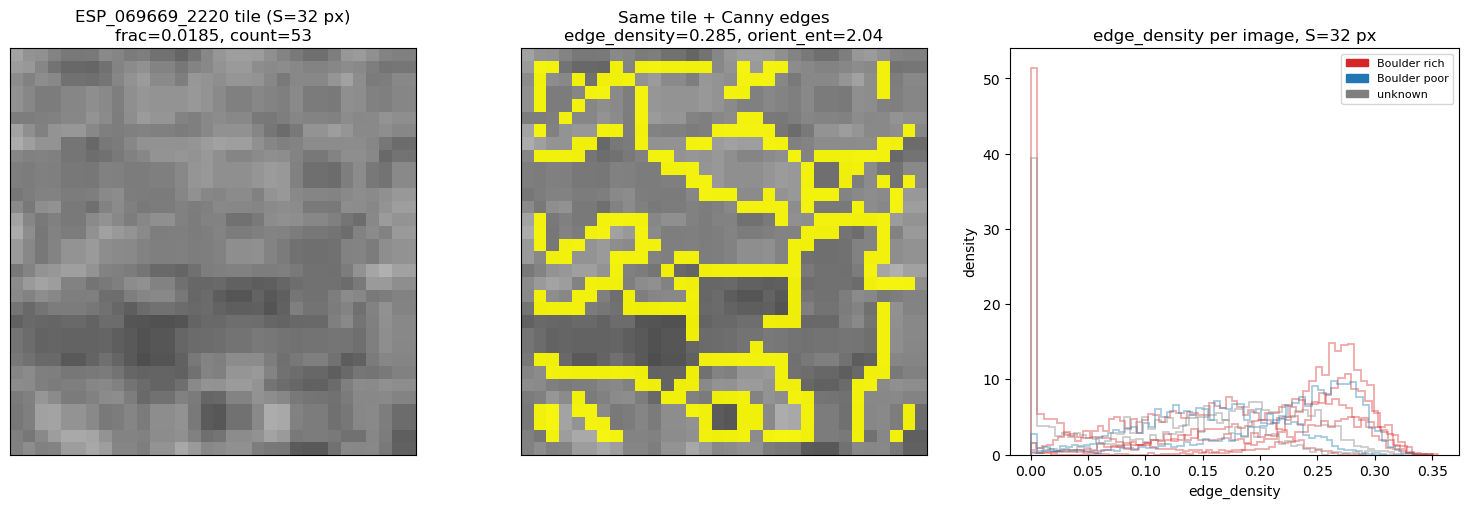

In [9]:
from skimage.feature import canny

# Pick a textured S=32 tile from ESP_069669_2220 to overlay Canny on.
ref_obs = 'ESP_069669_2220' if 'ESP_069669_2220' in obs_ids else obs_ids[0]
sub_ref = joined[(joined['obs_id'] == ref_obs) & (joined['tile_size_px'] == 32)]
sub_ref = sub_ref.sort_values('fractional_area', ascending=False)
top_tile = sub_ref.iloc[3]  # 4th-densest -- ample but not pathological
prov = load_features_provenance(ref_obs, cfg.output_dir)
ctx_path = Path(prov['ctx_window_tif'])
mosaic_row = prov['mosaic_row_origin']
mosaic_col = prov['mosaic_col_origin']
with rasterio.open(ctx_path) as src:
    arr = src.read(1)
S = int(top_tile['tile_size_px'])
r = int(top_tile['ti']) * S - mosaic_row
c = int(top_tile['tj']) * S - mosaic_col
tile = arr[r:r+S, c:c+S]
edges = canny(tile, sigma=1.0)

fig = plt.figure(figsize=(15, 5))

ax0 = fig.add_subplot(1, 3, 1)
ax0.imshow(tile, cmap='gray', vmin=0, vmax=255)
ax0.set_title(f'{ref_obs} tile (S=32 px)\nfrac={top_tile["fractional_area"]:.4f}, count={int(top_tile["boulder_count"])}')
ax0.set_xticks([]); ax0.set_yticks([])

ax1 = fig.add_subplot(1, 3, 2)
ax1.imshow(tile, cmap='gray', vmin=0, vmax=255)
ax1.imshow(np.ma.masked_where(~edges, edges), cmap='autumn', alpha=0.9, vmin=0, vmax=1)
ax1.set_title(f'Same tile + Canny edges\nedge_density={top_tile["edge_density"]:.3f}, '
              f'orient_ent={top_tile["edge_orientation_entropy"]:.2f}')
ax1.set_xticks([]); ax1.set_yticks([])

# Per-image distribution panel.
ax2 = fig.add_subplot(1, 3, 3)
s32 = joined[joined['tile_size_px'] == 32]
for obs in obs_ids:
    sub = s32[s32['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    ax2.hist(sub['edge_density'].dropna(), bins=60, alpha=0.4, color=LABEL_COLORS[lab],
             density=True, histtype='step', linewidth=1.3)
ax2.set_xlabel('edge_density')
ax2.set_ylabel('density')
ax2.set_title('edge_density per image, S=32 px')
patches_leg = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
ax2.legend(handles=patches_leg, fontsize=8, loc='upper right')

fig.tight_layout()
fig.savefig(FIG_DIR / '08_canny.png', dpi=110)
plt.show()


## 9. `context_patch` -- raw CTX uint8 chips for the CNN baseline

**What it is.** Two raw CTX patches per tile, centered on the tile center: one
32x32 px (= 160 m, equal to a coarse-grid tile) and one 64x64 px (= 320 m, equal to the
coarsest tile we emit). Stored *not* as one file per tile but as **bundled `(n, P, P)`
uint8 stacks per (ObsId, patch size)** -- 18 files total for the 9 ObsIds x 2 sizes.

**What it provides.** Unlike the tabular features, patches are *not lossy*: they're the
exact CTX pixels around each tile, ready for a CNN to learn its own representation. The
PLAN_modeling.md Week-3 CNN baseline reads these directly.

**Why bundled instead of per-tile files.** The plan literally prescribed
`{ObsId}/S{px}/{ti}_{tj}.npy` (1.3M small files). On NTFS this is brutal: slow
`os.scandir`, slow rsync, slow git status, every DataLoader open() going through a
filesystem-cache miss. Bundling into per-(ObsId, size) `.npy` stacks gives the same
random-access via `mmap_mode='r'` with 18 files instead of 1.3M, and total disk is the
same (3.3 GB for the whole sweep).

**The features parquet stores integer indices** -- `patch_idx_S32` and `patch_idx_S64`,
both int32 -- into the per-ObsId stack. `-1` means the tile is too close to the CTX
window edge for a centered patch to fit; only ~40 / ~400 tiles out of 643,910 hit that
case at S=32 / S=64. To load a patch for row $i$ in the features parquet:

```python
patches = np.load(f"dataset/context_patches/{obs}_S64.npy", mmap_mode='r')
idx = int(features_df.iloc[i]["patch_idx_S64"])
patch = patches[idx]  # (64, 64) uint8 view; .copy() if you'll mutate
```

The next section (§10) uses this to render the stratified high-vs-low boulder patch
viewer.


## 10. Stratified patch viewer -- where does "boulder rich" start being visible?

The headline question this notebook answers: **at what `fractional_area` do boulders
become visible in the CTX patches?** The labels parquet emits four candidate label
transforms (`fractional_area`, `binary_by_area`, `binary_by_count`, `count_density`)
but the right threshold and the right label *type* depend on what's actually
discriminable in the imagery. This is the visual investigation.

Below: 5 quantile buckets of `fractional_area`, sampled at the finest scale (S=8 px =
40 m). For each bucket we display **6 patches at S=32 (160 m context) and 6 patches at
S=64 (320 m context)**, sampled across the 9 ObsIds so you see the dataset's full
visual range, not just one image's appearance.

Buckets:

| Bucket | `fractional_area` range | Meaning |
|---|---|---|
| **zero** | `== 0` | True-zero tiles (HiRISE covered, no boulders detected). 97.9% of finest tiles. |
| **very low** | `(0, P25_nonzero]` | The first quartile of non-zero tiles. Where label noise / single-pixel boulders live. |
| **low** | `(P25, P50_nonzero]` | Second quartile non-zero. Light boulder coverage. |
| **med** | `(P50, P90_nonzero]` | The middle of the non-zero distribution. |
| **high** | `> P90_nonzero` | The top 10% of non-zero tiles. Densest boulder fields. |

Reading the figure:
- **If the "very low" patches look identical to "zero"**, then `binary_by_area` at a
  low threshold like 0.001 is mostly noise -- raise the threshold or switch to a
  count-based or `>= some_higher_frac` rule.
- **If "low" and "med" already show visible boulders**, a `binary_by_area` rule above
  the noise floor (e.g. 0.003-0.005) is meaningful.
- **If only "high" looks visibly different**, that argues for binning into a 2-3
  category label (categorical) or sticking with continuous `fractional_area` regression
  with log1p.


Bucket cut points (computed from non-zero finest tiles, n=10,344):
  zero:     fractional_area == 0  (n=478,210)
  very low: (0,         0.00375]
  low:      (0.00375, 0.00562]
  med:      (0.00562, 0.02062]
  high:     > 0.02062
Reference: labeling.binary_area_threshold (placeholder) = 0.005


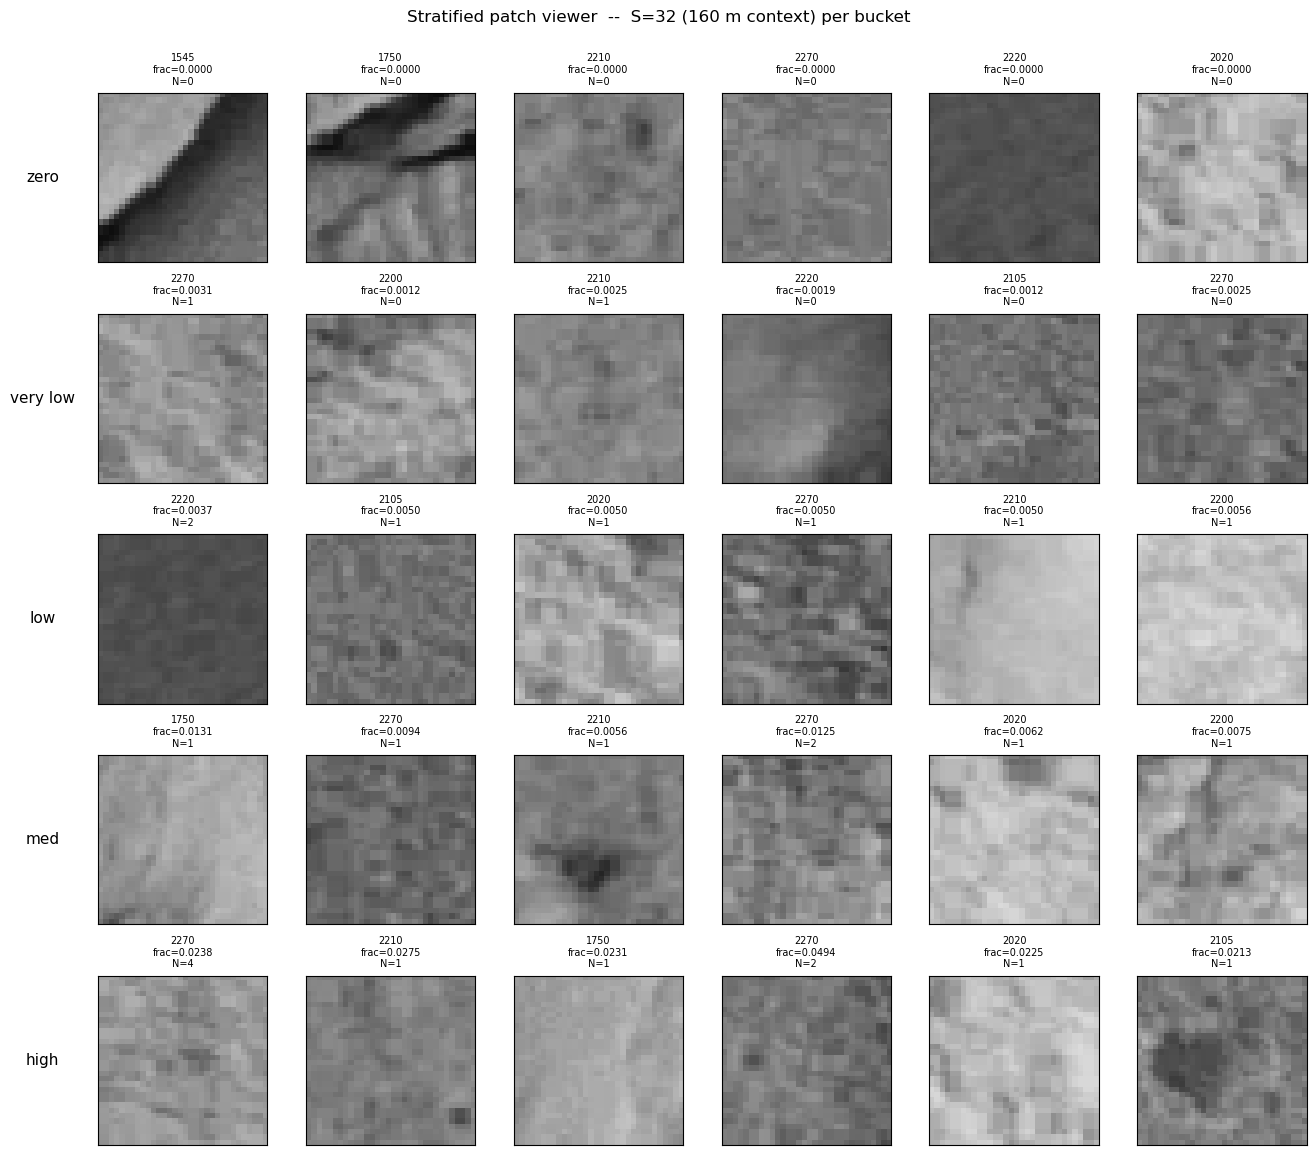

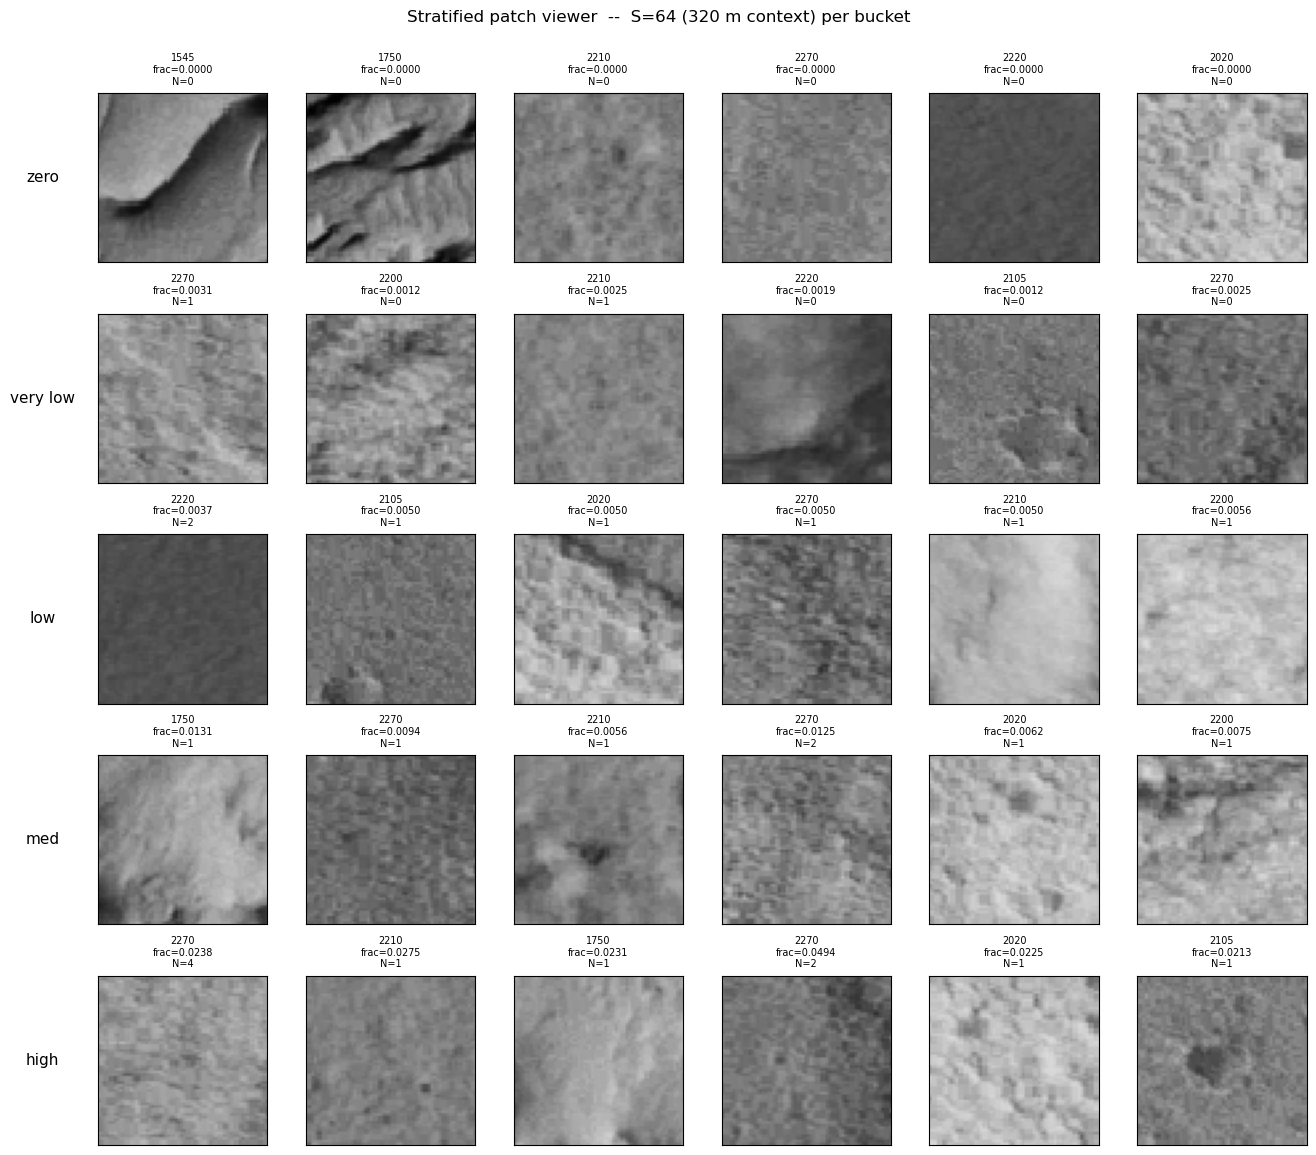

In [10]:
def sample_stratified_patches(buckets_n=6, patch_size_px=32, seed=0):
    '''Sample `buckets_n` tiles per fractional_area bucket, spread across ObsIds.

    Returns a list of dicts: {bucket, obs_id, ti, tj, fractional_area, boulder_count,
    patch}. patch is the (P, P) uint8 array loaded from the bundled .npy via memmap.
    '''
    rng = np.random.default_rng(seed)
    finest_local = finest.copy()
    nonzero = finest_local[finest_local['fractional_area'] > 0]['fractional_area'].to_numpy()
    p25 = float(np.quantile(nonzero, 0.25))
    p50 = float(np.quantile(nonzero, 0.50))
    p90 = float(np.quantile(nonzero, 0.90))
    edges = [(0.0, 0.0), (1e-12, p25), (p25, p50), (p50, p90), (p90, 1.1)]
    bucket_names = ['zero', 'very low', 'low', 'med', 'high']

    out = []
    # Cache patch stacks per (obs, P).
    patch_cache = {}
    def get_patches(obs, P):
        key = (obs, P)
        if key not in patch_cache:
            patch_cache[key] = load_context_patches(obs, P, cfg.output_dir)
        return patch_cache[key]

    for name, (lo, hi) in zip(bucket_names, edges):
        if name == 'zero':
            pool = finest_local[finest_local['fractional_area'] == 0]
        else:
            pool = finest_local[(finest_local['fractional_area'] > lo) & (finest_local['fractional_area'] <= hi)]
        # Stratify across ObsIds: sample ~equal numbers per image, fall back to random
        # if some image has nothing in this bucket.
        per_image = max(1, buckets_n // len(obs_ids))
        rows = []
        for obs in obs_ids:
            obs_pool = pool[pool['obs_id'] == obs]
            if len(obs_pool) == 0:
                continue
            n = min(per_image, len(obs_pool))
            chosen = obs_pool.sample(n=n, random_state=rng.integers(0, 1_000_000))
            rows.append(chosen)
        if rows:
            picked = pd.concat(rows).sample(n=min(buckets_n, sum(len(r) for r in rows)),
                                              random_state=rng.integers(0, 1_000_000))
        else:
            picked = pool.sample(n=min(buckets_n, len(pool)),
                                  random_state=rng.integers(0, 1_000_000))
        for _, row in picked.iterrows():
            idx = int(row[f'patch_idx_S{patch_size_px}'])
            if idx < 0:
                continue  # tile too close to window edge; skip
            patches = get_patches(row['obs_id'], patch_size_px)
            out.append({
                'bucket': name, 'obs_id': row['obs_id'], 'ti': int(row['ti']), 'tj': int(row['tj']),
                'fractional_area': float(row['fractional_area']),
                'boulder_count': int(row['boulder_count']),
                'patch': np.asarray(patches[idx]),
                'label': row['label'],
            })
    return out, bucket_names

samples_S32, bucket_names = sample_stratified_patches(buckets_n=6, patch_size_px=32, seed=0)
samples_S64, _ = sample_stratified_patches(buckets_n=6, patch_size_px=64, seed=0)

def render_grid(samples, patch_size, title, fig_path):
    fig, axes = plt.subplots(len(bucket_names), 6, figsize=(13.5, len(bucket_names) * 2.3))
    if axes.ndim == 1:
        axes = axes[None, :]
    for row_idx, bucket in enumerate(bucket_names):
        bucket_samples = [s for s in samples if s['bucket'] == bucket][:6]
        for col_idx in range(6):
            ax = axes[row_idx, col_idx]
            if col_idx < len(bucket_samples):
                s = bucket_samples[col_idx]
                ax.imshow(s['patch'], cmap='gray', vmin=0, vmax=255)
                ax.set_title(f'{s["obs_id"][-4:]}\nfrac={s["fractional_area"]:.4f}\nN={s["boulder_count"]}',
                             fontsize=7)
            else:
                ax.axis('off')
            ax.set_xticks([]); ax.set_yticks([])
        axes[row_idx, 0].set_ylabel(bucket, fontsize=11, rotation=0, labelpad=40, va='center')
    fig.suptitle(title, fontsize=12, y=1.00)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=110)
    plt.show()

# Print the bucket cut points so the user can see what fractional_area ranges they're
# looking at.
nonzero_finest = finest[finest['fractional_area'] > 0]['fractional_area'].to_numpy()
print(f'Bucket cut points (computed from non-zero finest tiles, n={len(nonzero_finest):,}):')
print(f'  zero:     fractional_area == 0  (n={int((finest["fractional_area"] == 0).sum()):,})')
print(f'  very low: (0,         {np.quantile(nonzero_finest, 0.25):.5f}]')
print(f'  low:      ({np.quantile(nonzero_finest, 0.25):.5f}, {np.quantile(nonzero_finest, 0.50):.5f}]')
print(f'  med:      ({np.quantile(nonzero_finest, 0.50):.5f}, {np.quantile(nonzero_finest, 0.90):.5f}]')
print(f'  high:     > {np.quantile(nonzero_finest, 0.90):.5f}')
print(f'Reference: labeling.binary_area_threshold (placeholder) = 0.005')

render_grid(samples_S32, 32,
            'Stratified patch viewer  --  S=32 (160 m context) per bucket',
            FIG_DIR / '08_patches_stratified_S32.png')
render_grid(samples_S64, 64,
            'Stratified patch viewer  --  S=64 (320 m context) per bucket',
            FIG_DIR / '08_patches_stratified_S64.png')


### Patch viewer -- threshold-band detail

The buckets above are quantile-based; the panel below cuts on **specific candidate
threshold values** so you can see exactly what `binary_by_area` would call a positive
vs negative at the current placeholder (0.005) and at neighbouring candidates (0.001,
0.01, 0.05). Each row is "patches whose `fractional_area` sits within this narrow band
around the threshold".


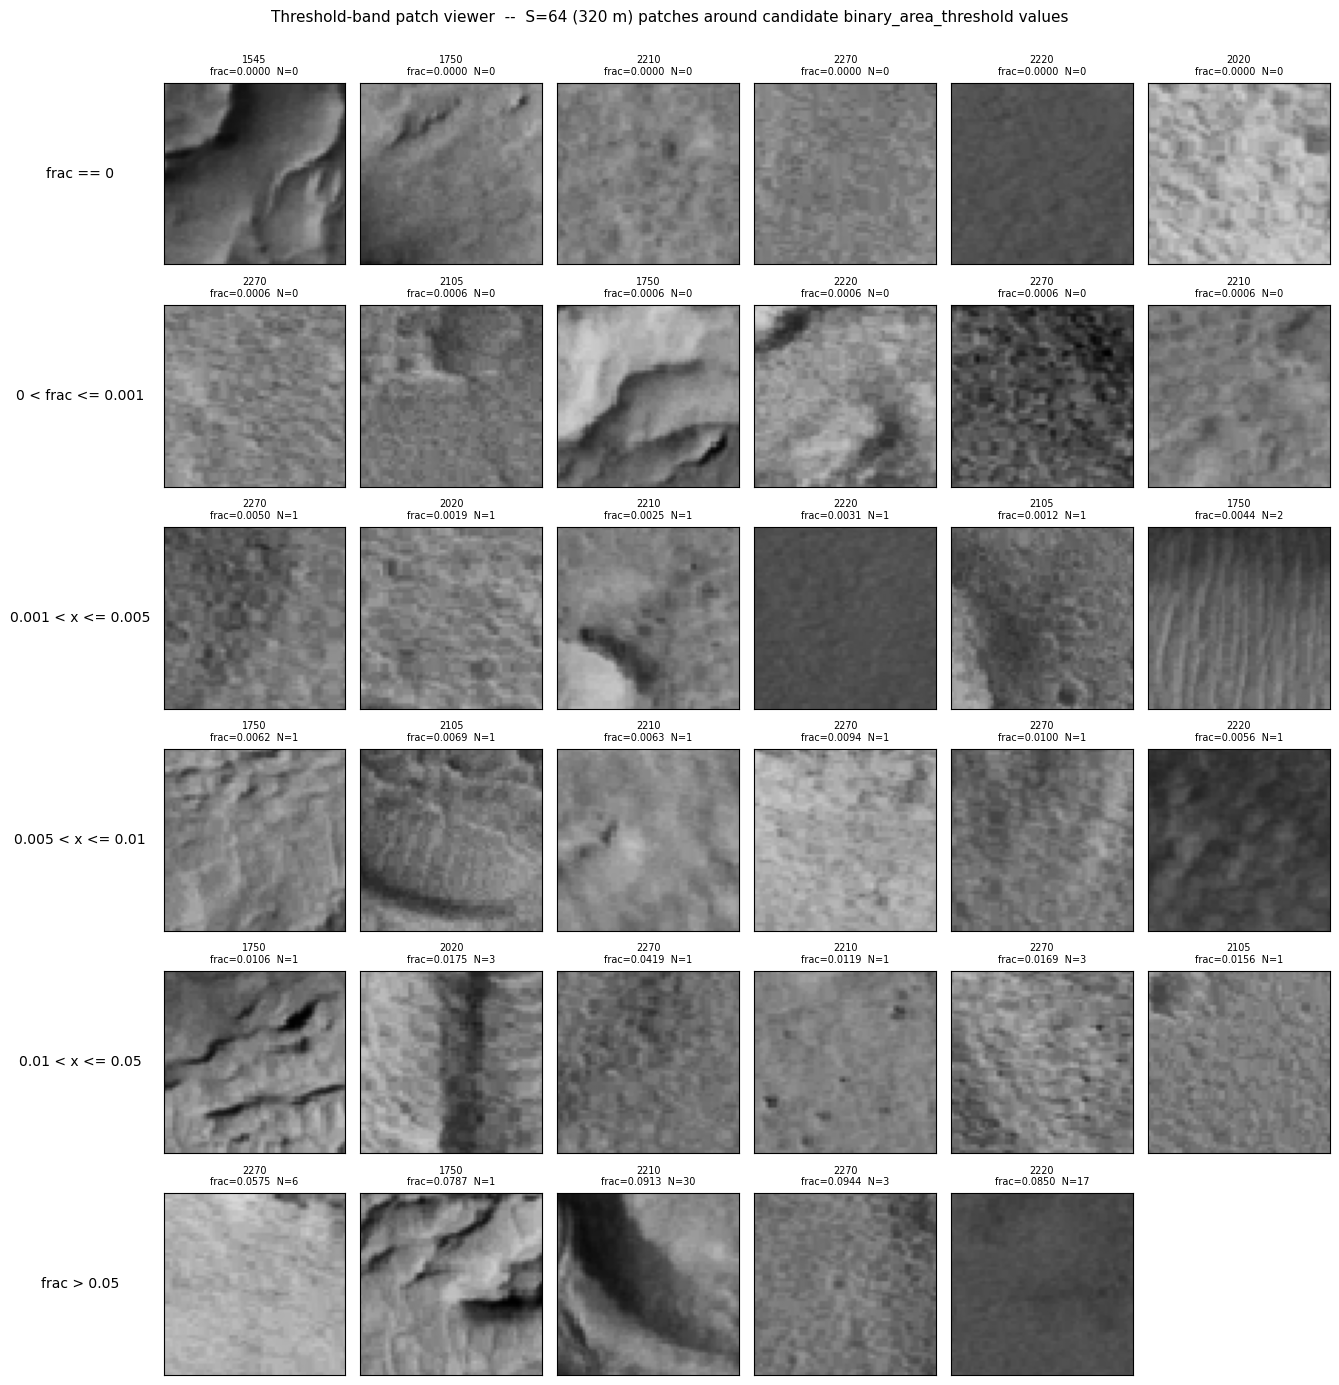

In [11]:
band_specs = [
    ('frac == 0',          lambda x: x == 0),
    ('0 < frac <= 0.001',  lambda x: (x > 0)      & (x <= 0.001)),
    ('0.001 < x <= 0.005', lambda x: (x > 0.001)  & (x <= 0.005)),  # below current threshold
    ('0.005 < x <= 0.01',  lambda x: (x > 0.005)  & (x <= 0.01)),   # just above current threshold
    ('0.01 < x <= 0.05',   lambda x: (x > 0.01)   & (x <= 0.05)),
    ('frac > 0.05',        lambda x: x > 0.05),
]

def sample_band_patches(predicate, patch_size_px, n=6, seed=0):
    rng = np.random.default_rng(seed)
    pool = finest[predicate(finest['fractional_area'])]
    pool = pool[pool[f'patch_idx_S{patch_size_px}'] >= 0]
    if len(pool) == 0:
        return []
    per_image = max(1, n // len(obs_ids))
    rows = []
    for obs in obs_ids:
        obs_pool = pool[pool['obs_id'] == obs]
        if len(obs_pool) == 0:
            continue
        k = min(per_image, len(obs_pool))
        rows.append(obs_pool.sample(n=k, random_state=rng.integers(0, 1_000_000)))
    if rows:
        picked = pd.concat(rows).sample(n=min(n, sum(len(r) for r in rows)),
                                          random_state=rng.integers(0, 1_000_000))
    else:
        picked = pool.sample(n=min(n, len(pool)), random_state=rng.integers(0, 1_000_000))
    patches = {}
    out = []
    for _, row in picked.iterrows():
        obs = row['obs_id']
        if obs not in patches:
            patches[obs] = load_context_patches(obs, patch_size_px, cfg.output_dir)
        idx = int(row[f'patch_idx_S{patch_size_px}'])
        out.append({'obs_id': obs, 'frac': float(row['fractional_area']),
                    'count': int(row['boulder_count']),
                    'patch': np.asarray(patches[obs][idx])})
    return out

# Render the band grid at S=64 (richer context).
fig, axes = plt.subplots(len(band_specs), 6, figsize=(13.5, len(band_specs) * 2.3))
for row_idx, (name, predicate) in enumerate(band_specs):
    samples = sample_band_patches(predicate, patch_size_px=64, n=6, seed=row_idx)
    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        if col_idx < len(samples):
            s = samples[col_idx]
            ax.imshow(s['patch'], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'{s["obs_id"][-4:]}\nfrac={s["frac"]:.4f}  N={s["count"]}',
                         fontsize=7)
        else:
            ax.axis('off')
        ax.set_xticks([]); ax.set_yticks([])
    axes[row_idx, 0].set_ylabel(name, fontsize=10, rotation=0, labelpad=60, va='center')
fig.suptitle('Threshold-band patch viewer  --  S=64 (320 m) patches around candidate '
             'binary_area_threshold values',
             fontsize=11, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_patches_threshold_bands_S64.png', dpi=110)
plt.show()


## Reading the patch viewer for label-design decisions

A few questions to answer by eye from the figures above:

1. **At what fractional_area do boulders first become visible?** Scan from `zero` ->
   `very low` -> `low` and find the first row where you can pick out individual boulder
   shadows. That's where a binary threshold becomes meaningful.

2. **Is the `binary_area_threshold = 0.005` (current placeholder) above or below the
   visibility floor?** Look at the threshold-band figure: the `0.001 < x <= 0.005` row
   shows tiles classified as 0 today; `0.005 < x <= 0.01` shows tiles classified as 1.
   If the two rows look indistinguishable, the threshold is too low; if `0.005 < x <=
   0.01` already shows clear boulder fields, the threshold may be fine.

3. **Categorical vs continuous?** If the visual transitions across buckets are smooth
   (`zero` -> `very low` -> `low` -> ... look like a gradient), a continuous regression
   target like `fractional_area` (perhaps log1p-transformed for the heavy tail) is the
   right call. If they're sharp (a clear visual cliff between two buckets), a binary or
   categorical label is more natural.

4. **Does `boulder_count` (`N=` in each panel's title) track the visible boulder count?**
   A row with N=10 should show ~10 visible boulder signatures; if it shows a lot fewer
   or a lot more, the `count`-based labels are noisy and a `binary_by_count` rule needs
   to be more cautious than `binary_by_area`.

5. **Are the boulder-rich and boulder-poor manifest labels supported by the imagery?**
   The non-zero rows draw mostly from the boulder-rich images (which is why even very-
   low non-zero fractional_area tiles come predominantly from them); the `zero` row
   draws from all 9. If you spot a `zero` patch that visibly contains boulders, that's
   evidence of BoulderNet missing detections -- worth chasing up.

The DECISIONS.md 2026-05-23 Stage 4 entry already records that `binary_count_threshold
= 5` is too strict relative to `binary_area_threshold = 0.005` (only 2 count-only tiles
vs 5,504 area-only). This notebook gives the visual basis to pick the actual replacement
values; record the choice in DECISIONS.md alongside the binary-thresholds change in
`config.yaml`, and Stage 4 re-runs in ~3 seconds per image.
